# <u>Intro to statistics - part 3: confidence intervals</u>

## Introduction


# 1. Theory and definitions

## Confidence intervals

Confidence intervals play an important role in assessing the uncertainties associated with a probabilistic model. By definition, a confidence interval of a random variable is a specified range of values for which there is a given probability that the interval encompasses the true value of the random variable. The confidence interval is characterized by this probability, i.e., a $95\%$ confidence interval assumes a probability of $p = 0.95$ that the true value of the random variable will be within the given confidence interval. Another often used measure is the confidence level $\alpha = 1 - p$, i.e., a $95\%$ confidence interval corresponds to a confidence level of $\alpha = 0.05$.
A confidence interval is an observed interval, meaning that it is calculated from observations, and is different from sample to sample. It should also be noted that the confidence interval is usually centered at the mean value of the sample, and there is equal probability for exceeding the upper or the lower limits of the interval, i.e., for a confidence level $\alpha = 0.05$ the probability of the true value being less than the lower end of the interval is $0.025$, the same as the probability of the true value being higher than the upper end of the interval. 

Possibly the simplest illustration of a confidence interval is the case of a Normally distributed random variable $X$ with known mean $\mu_X$ and standard deviation $\sigma_X$. Then, the confidence interval for $X$ at confidence level $\alpha$ can be determined as

$CI_{\pm}(X) = \mu_X \pm \Phi^{-1}(1 - \alpha/2)\sigma_X$

where $\Phi()$ denotes the cumulative distribution function of the standard Normal distribution. Similarly for other distributions there is a close connection between the cdf and the confidence interval, as the cdf provides a measure of the probability of a variable being higher or lower than a certain value. 

If the true properties (e.g. mean and variance, and distribution cdf) of the random variable are not known, but instead need to be determined from a random sample of the variable, confidence intervals can also be obtained based on the sample statistics. However, the confidence interval needs to be broader to take into account the higher uncertainty (remember that the finite sample size means the sample statistics are an uncertain estimate of the true properties of the population). For Normally distributed populations this can be accounted for by using the student's t-distribution. The student's t-distribution resembles a Normal distribution however it has an additional parameter - the "degrees of freedom" which corresponds to the number of samples used to estimate the sample statistics. To illustrate, for a random sample of size $n$ with mean $M$ and sample standard deviation $S$, the confidence interval can be estimated as 

$CI_{\pm}(X) = M \pm T^{-1}(1 - \alpha/2, n - 1)S$

where $T^{-1}(1 - \alpha/2, n - 1)$ denotes the inverse student's t-distribution at probability level $(1 - \alpha/2)$ and with $(n-1)$ degrees of freedom. 

The above formulas define specifically the confidence interval with respect to the probability of a single observation from a Normally distributed variable falling within a specific interval. It is also possible to calculate confidence intervals for the __mean value__ $\bar{y}$ of a sample with size $n$. In many cases it will be reasonable to assume that the mean values of repeated realizations of a random sample will be normally distributed (why?). For a population with known mean $\mu_X$ and standard deviation $\sigma_X$, the sample mean of a sample with size $n$ will be a random variable with mean $\mu_X$ and standard deviation $\sigma_X/\sqrt{n}$. This leads to the following expression for the confidence interval for $\bar{x}$:

$CI_{\pm}(\bar{x}) = $\mu_X$ \pm \Phi^{-1}(1 - \frac{\alpha}{2})\frac{\sigma_X}{\sqrt{n}}$

Just as in the case of single realizations, not knowing the population variance means we could use the sample mean $M$ and variance $S$ together with the student's t-distribution instead:

$CI_{\pm}(\bar{x}) = M \pm t_{n-1,\frac{\alpha}{2}} \frac{\sigma_X}{\sqrt{n}}$

where we denoted
$t_{n-1,\frac{\alpha}{2}} = T^{-1}\left( \frac{\alpha}{2}, n - 1 \right) = T^{-1}\left( 1 - \frac{\alpha}{2}, n - 1 \right)$

For such an approach, about 20-30 samples would usually give a good confidence estimate as the sample variance becomes a reasonable estimate of the true variance. At about 30 degrees of freedom, the student's t-distribution becomes almost identical to the Normal distribution.


## Bootstrapping
When only a single input data set is available it is not possible to directly estimate the variance of the model estimate. In such cases the confidence intervals can be determined by bootstrapping (Efron, 1979). Here the non-parametric bootstrapping technique is described, where the distribution of the response variable $Y = f(\mathbf{X})$ is determined purely empirically by creating a number of realisations of an input sample $\mathbf{x_1, x_2, \ldots, x_l}$. The bootstrap samples are drawn from the original input sample the following way: first, all the data points from the input sample of size $N$ are given an integer index number $[1,N]$. Then a new bootstrap sample of size $N$ is created by drawing $N$ random integers from the interval $[1,N]$. The new sample is constructed from the datapoints from the original sample with indexes corresponding to the generated set of integers. Since the drawing procedure allows number repetitions, the resulting sample will in most cases differ from the original sample. Confidence intervals can be obtained based on the variance of the bootstrap sample by equation \ref{eq:ConfInt01}. If one wants to avoid the assumption of normality of the bootstrap sample, the empirical distribution function of the bootstrap sample can be obtained by ranking the sampled response realisations $y_i = f(x_i)$ according to their values. If $l$ number of bootstrap samples have been realised, and the set of obtained responses, ranked by value is designated as $R^*$, with the $i^{th}$ ranked value being $R^*_{i}$, then the lower and upper bounds with a confidence level of $1 - q$ are determined by:

$CI_{-} = R^*_{[ql/2]} \qquad, \qquad CI_{+} = R^*_{[(1-q/2)/l]}$

where the square brackets $[a]$ mean the integer part of $a$. This technique for estimating confidence intervals is as simple to apply as the variance based method, but there are no assumptions made about the distribution of the error. However this comes at the expense of having to generate much larger sample. Typically 1000 or more samples will be necessary for obtaining a good estimate using the empirical cdf of the bootstrap sample and the equation above.

# 2. Programming exercise

We have annual-average wind speed data based on measurements at the Høvsøre site in Denmark for 8 years:

| Year # |  1  |  2  |  3  |  4  |  5  |  6  |  7  |  8  |
|--------|-----|-----|-----|-----|-----|-----|-----|-----|
|$U_{mean}$| 8.97| 8.56| 9.11| 8.79| 8.27| 8.40| 9.56| 8.02|


Estimate the expected value of the long-term average wind speed $\bar{U}$ and the 95% confidence bounds for $\bar{U}$ using:

- Bootstrapping
- Student’s t-distribution with 7 degrees of freedom
- Normal distribution

### Confidence intervals using the Normal distribution


As usually we start with importing libraries - we'll need Numpy and Scipy.Stats, as well as Matplotlib for plotting.

In [37]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

In [38]:
N0 = 1000
N = 3 + np.random.randn(N0)*2.2
Nmeans = []
for i in range(100000):
    Ni = np.random.choice(N, size = N0)
    Nmeans.append(np.mean(Ni))
np.std(Nmeans)/np.std(N)

0.03156678237218577

In [23]:
import matplotlib.pyplot as plt

(array([1.0000e+00, 4.0000e+00, 9.0000e+00, 2.7000e+01, 5.2000e+01,
        1.4500e+02, 3.4200e+02, 6.9300e+02, 1.3150e+03, 2.3560e+03,
        3.7830e+03, 5.5200e+03, 7.7650e+03, 9.3290e+03, 1.1051e+04,
        1.1369e+04, 1.1013e+04, 9.8630e+03, 8.3550e+03, 6.3910e+03,
        4.2840e+03, 2.8470e+03, 1.7230e+03, 9.5800e+02, 4.6200e+02,
        2.0100e+02, 9.7000e+01, 2.6000e+01, 1.6000e+01, 3.0000e+00]),
 array([2.70312041, 2.72276605, 2.7424117 , 2.76205734, 2.78170298,
        2.80134862, 2.82099426, 2.8406399 , 2.86028555, 2.87993119,
        2.89957683, 2.91922247, 2.93886811, 2.95851375, 2.97815939,
        2.99780504, 3.01745068, 3.03709632, 3.05674196, 3.0763876 ,
        3.09603324, 3.11567889, 3.13532453, 3.15497017, 3.17461581,
        3.19426145, 3.21390709, 3.23355273, 3.25319838, 3.27284402,
        3.29248966]),
 <BarContainer object of 30 artists>)

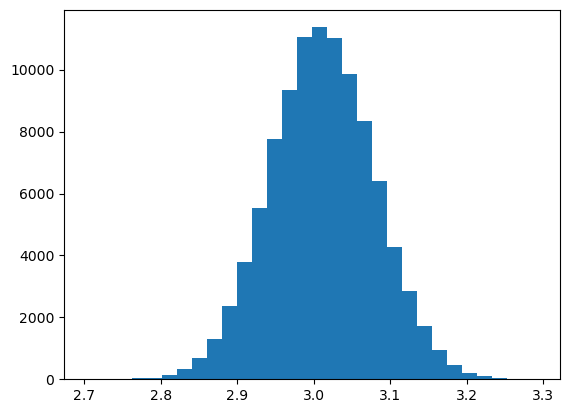

In [39]:
plt.hist(Nmeans,30)

In [40]:
# Compute the sample mean and standard deviation and define confidence levels

U = [8.97, 8.56, 9.11, 8.79, 8.27, 8.40, 9.56, 8.02]

Umean = np.mean(U)
Ustd = np.std(U)

alpha = 1 - 0.95 # Corresponding to 95% probability  ( alpha = 1-p)

n = len(U) # Count the number of samples

In [41]:
n

8

In [42]:
# Confidence intervals using directly the Standard Normal distribution

CIn_N = Umean - stats.norm.ppf(1 - alpha/2)*Ustd/np.sqrt(n)
CIp_N = Umean + stats.norm.ppf(1 - alpha/2)*Ustd/np.sqrt(n)

print('Confidence interval based on the Normal distribution: [' + str(CIn_N) + ', ' + str(CIp_N) + ']')

Confidence interval based on the Normal distribution: [8.386383296013365, 9.033616703986636]


We know that a Normally distributed variable with mean $\mu$ and standard deviation $\sigma$ can also be expressed through the standard normal distribution, i.e., $F_N(x, \mu, \sigma) = \Phi( \frac{x - \mu}{\sigma})$. So it means that we could also estimate confidence intervals by directly using *stats.norm.ppf* if we also specify the mean and standard deviation:

In [43]:
# Normal confidence intervals - another way of doing it with the actual mean and std.dev. 
# Are the results the same?

CIn_N1 = stats.norm.ppf((alpha/2), loc = Umean, scale = Ustd/np.sqrt(n))
CIp_N1 = stats.norm.ppf((1 - alpha/2), loc = Umean, scale = Ustd/np.sqrt(n))

print('Confidence interval based on the Normal distribution: [' + str(CIn_N1) + ', ' + str(CIp_N1) + ']')

Confidence interval based on the Normal distribution: [8.386383296013365, 9.033616703986636]


### Confidence intervals based on the student's t-distribution

The student's t-distribution is available in scipy as *stats.t*. The inverse t can be computed as *stats.t.ppf(q, df)* where *q* is the quantile and *df* the degrees of freedom. Note that this implementation of student's t-distribution is with zero mean and unit variance.

In [44]:

CIn_T = Umean - stats.t.ppf(1 - alpha/2, df = (n-1))*Ustd/np.sqrt(n)
CIp_T = Umean + stats.t.ppf(1 - alpha/2, df = (n-1))*Ustd/np.sqrt(n)

print('Confidence interval based on the student''s t-distribution: [' + str(CIn_T) + ', ' + str(CIp_T) + ']')

Confidence interval based on the students t-distribution: [8.319568383748441, 9.10043161625156]


### Confidence intervals based on bootstrapping

In [68]:
Nbootstrap = 99999
BootstrapSize = len(U)

Bsample = np.random.choice(U, size = (BootstrapSize,Nbootstrap))
BootstrapMeans = np.sort(Bsample.mean(0))
        
Rlow = int((Nbootstrap+1)*alpha/2) - 1
Rhigh = int((Nbootstrap+1)*(1-alpha/2)) - 1

CIn_B = BootstrapMeans[Rlow]
CIp_B = BootstrapMeans[Rhigh]

print('Confidence interval based on bootstrapping: [' + str(CIn_B) + ', ' + str(CIp_B) + ']')

Confidence interval based on bootstrapping: [8.3975, 9.04]


In [69]:
Rlow

2499

In [70]:
Fempirical = np.arange(1,Nbootstrap+1)/(Nbootstrap + 1)
Fempirical[Rhigh]

0.975

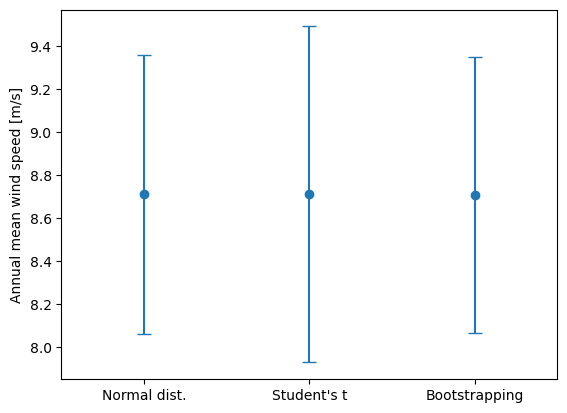

In [47]:
# Plot errorbars
fig0, ax0 = plt.subplots()
ax0.errorbar([1, 2, 3], [Umean, Umean, np.mean(BootstrapMeans)],
             yerr = [(CIp_N - CIn_N), (CIp_T - CIn_T), (CIp_B - CIn_B)],
            linestyle = '',marker = 'o',capsize = 5)
ax0.set_xlim([0.5,3.5])
ax0.set_xticks([1,2,3])
ax0.set_xticklabels(['Normal dist.','Student\'s t','Bootstrapping'])
ax0.set_ylabel('Annual mean wind speed [m/s]')
plt.show()

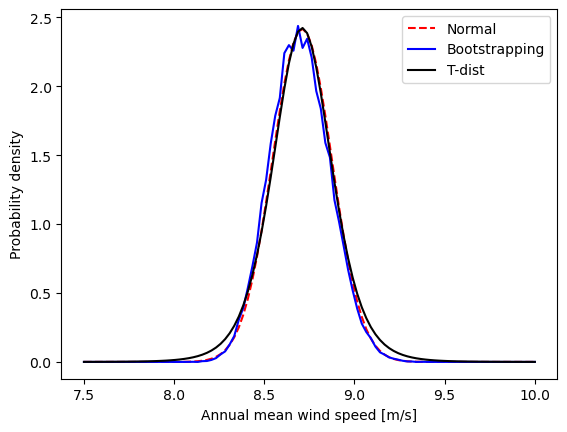

In [71]:
# Plot pdfs

Ubins = np.linspace(7.5,10,100)

pdf_N = stats.norm.pdf(Ubins,Umean,Ustd/np.sqrt(n))
dU = Ubins[1]-Ubins[0] # Scaling factor for the t-pdf to make sure we get a valid pdf for every bin spacing
pdf_T = (1/np.sqrt(dU))*stats.t.pdf((Ubins - Umean)/(Ustd/np.sqrt(n)), n - 1)

# Generating an empirical pdf from the bootstrap sample
BootstrapHist = np.histogram(BootstrapMeans,bins = Ubins)
BootstrapDist = stats.rv_histogram(BootstrapHist)
pdf_B = BootstrapDist.pdf(Ubins)

fig1, ax1 = plt.subplots()
p11 = ax1.plot(Ubins,pdf_N,'--r', label = 'Normal')
p12 = ax1.plot(Ubins,pdf_B,'-b', label = 'Bootstrapping')
p13 = ax1.plot(Ubins,pdf_T,'-k', label = 'T-dist')
plt.xlabel('Annual mean wind speed [m/s]')
plt.ylabel('Probability density')
plt.legend()

plt.show()